# Axions in CLASSpp: exact scalar-field treatment and the pheno-axion EDE fluid

**Summary and test of changes in PR [#370](https://github.com/AarhusCosmology/CLASSpp/pull/370)** — branch `axion-species`.

This notebook is a short report on the two axion components added to CLASSpp, following
Vivian Poulin's [AxiCLASS](https://github.com/PoulinV/AxiCLASS) as the physics reference
(Poulin et al. [arXiv:1806.10608](https://arxiv.org/abs/1806.10608),
[arXiv:1811.04083](https://arxiv.org/abs/1811.04083); Smith et al.
[arXiv:1905.12618](https://arxiv.org/abs/1905.12618)):

1. **An exact axion potential for `ScalarFieldSpecies`** — the Klein–Gordon equation is
   integrated throughout, valid whenever the field oscillates slowly enough for the ODE
   to resolve (axion dark energy, late oscillation onset).
2. **The pheno-axion effective early-dark-energy (EDE) fluid** — AxiCLASS's
   `pheno_axion` parametrization: a fluid whose equation of state transitions from
   $w_i=-1$ to $w_f=\frac{n-1}{n+1}$ at scale factor $a_c$, with the
   Poulin et al. scale-dependent effective sound speed. This is the numerically cheap
   parametrization used in published EDE analyses, valid deep in the oscillatory regime
   where the exact treatment is intractable.

Design spec: `docs/superpowers/specs/2026-07-14-axion-species-design.md`.
Both features are strictly opt-in: default CLASSpp output is unchanged.

## 1. Physics background

An axion-like field $\phi$ with decay constant $f$ has the potential

$$V(\phi) = m^2 f^2 \left(1-\cos\frac{\phi}{f}\right)^n ,$$

which is $\tfrac12 m^2\phi^2$-like near the minimum for $n=1$ and flattens for larger $n$.
Hubble friction freezes the field at its initial misalignment angle
$\Theta_i = \phi_i/f$ until $H(a)$ drops to $\mathcal{O}(m)$; it then rolls and
oscillates. Averaged over oscillations the energy density dilutes as
$\rho\propto a^{-3(1+w_n)}$ with $w_n = \frac{n-1}{n+1}$
(Turner 1983): $n=1$ behaves like matter, $n=2$ like radiation, $n=3$ dilutes faster
than radiation ($w=1/2$) — the property that makes $n\geq 2$ axions interesting as
*early dark energy* resolving the $H_0$ tension.

**Two regimes, two tools.** From oscillation onset to today the field completes
$\sim m/H_0$ cycles; for the canonical EDE transition ($a_c\sim10^{-3.5}$) that is
$10^5$–$10^6$ oscillations *per Fourier mode* — hopeless for a direct ODE integration.
Component 1 therefore covers the slow regime exactly, and component 2 covers the
deep-oscillation regime with the effective fluid.

For the fluid, the background equation of state is the sigmoid ("mash-up of 1811.04083
and 1905.12618")

$$w(a) = w_i + \frac{w_f-w_i}{1+(a_c/a)^{r}},\qquad r = \frac{3(w_f-w_i)}{\nu},$$

whose density integral $\int_a^1 3\,\frac{1+w}{a'}\,\mathrm{d}a'$ has a closed form —
all density normalizations ($\Omega_{\rm fld,0}\leftrightarrow\Omega_{\rm fld}(a_c)
\leftrightarrow f_{\rm EDE}(a_c)$) are algebraic, no shooting involved. Perturbations
use the true fluid equations with the generalized-dark-matter effective sound speed
(1806.10608, Eq. 20)

$$c_s^2(k,a) = \frac{2a^2(n-1)\,\varpi^2 + k^2}{2a^2(n+1)\,\varpi^2 + k^2},
\qquad \varpi(a) \equiv \omega_{\rm axion}\, a^{-3(n-1)/(n+1)},$$

where $\omega_{\rm axion}$ is calibrated from $(a_c,\,\Omega_{\rm fld}(a_c),\,\Theta_i,\,n)$
per Eqs. 27/28/30 of 1806.10608.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from classy import Class

# House style: recessive grid/axes, thin marks, validated categorical palette
# (slots in fixed order; see PR #370 notes).
C1, C2, C3, C6 = "#2a78d6", "#1baf7a", "#eda100", "#e34948"
NEUTRAL = "#52514e"
matplotlib.rcParams.update({
    "figure.figsize": (8.0, 4.5), "figure.dpi": 110,
    "lines.linewidth": 2.0, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 12, "axes.titlesize": 13, "legend.frameon": False,
})

BASE = {"h": 0.67, "omega_b": 0.02238, "omega_cdm": 0.1201}

def run(extra, level=None, lmax=2500):
    cosmo = Class()
    cosmo.set({**BASE, **extra})
    cosmo.compute() if level is None else cosmo.compute(level=level)
    return cosmo

## 2. Component 1 — exact axion scalar field

**Input keys** (`explanatory.ini` documents all of them):

| key | meaning |
|---|---|
| `scf_potential = axion` | selects the $(1-\cos)^n$ potential bundle |
| `f_axion` | decay constant $f$ (reduced-Planck units, required) |
| `n_axion` | exponent $n\ge1$ (default 1) |
| `Theta_initial_scf` | misalignment angle $\Theta_i\in(0,\pi)$; frozen ICs $\phi_i=\Theta_i f$, $\phi_i'=0$ |
| `m_axion` | optional Newton seed (1/Mpc) |
| `Omega_scf` | shooting target — $m$ is **always** tuned so that $\Omega_{\rm scf}$ today matches |

The second derivative of the potential is implemented in the regular form
$V'' = m^2 n\, u^{n-1}\left[(n-1)(2-u) + (1-u)\right]$ with $u=1-\cos(\phi/f)$
(using $\sin^2 = u(2-u)$), which is finite at the minimum for all $n\ge1$ — the
AxiCLASS expression is singular there for $n=1$ and was deliberately not ported.

Below: an axion-dark-energy configuration ($n=1$, $f=0.5\,M_{\rm P}$, $\Theta_i=2$,
$\Omega_{\rm scf}=0.05$). The shooting resolves $m\simeq0.7H_0$: the field is frozen
($w\simeq-1$) through recombination and only begins to thaw today.

In [2]:
scf = run({"scf_potential": "axion", "f_axion": 0.5, "n_axion": 1,
           "Theta_initial_scf": 2.0, "Omega_scf": 0.05}, level=["background"])
bg = scf.get_background()
a = 1.0 / (1.0 + bg["z"])
o = np.argsort(a)
a_s = a[o]
w_scf = (bg["(.)p_scf"] / bg["(.)rho_scf"])[o]
f_scf = (bg["(.)rho_scf"] / bg["H [1/Mpc]"] ** 2)[o]

omega_today = f_scf[-1]
print(f"shooting hit: Omega_scf(a=1) = {omega_today:.7f}  (target 0.05)")

shooting hit: Omega_scf(a=1) = 0.0500003  (target 0.05)


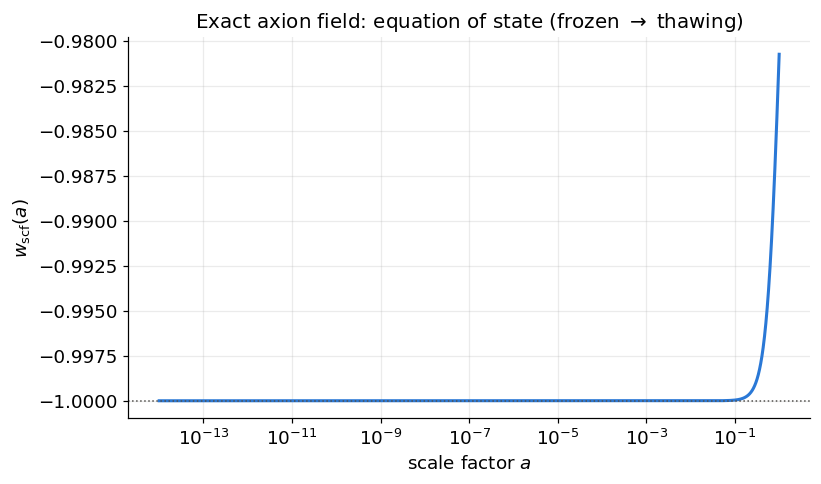

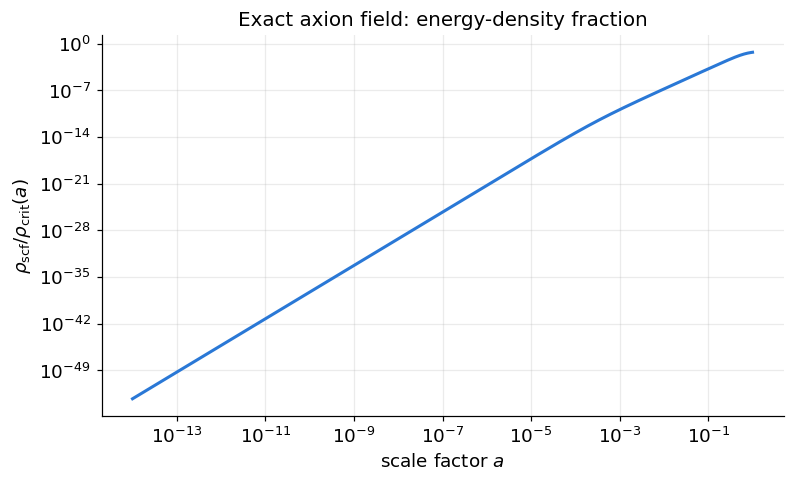

In [3]:
fig, ax = plt.subplots()
ax.semilogx(a_s, w_scf, color=C1)
ax.set(xlabel=r"scale factor $a$", ylabel=r"$w_{\rm scf}(a)$",
       title=r"Exact axion field: equation of state (frozen $\to$ thawing)")
ax.axhline(-1, color=NEUTRAL, lw=1, ls=":")
ax.annotate(r"frozen, $w=-1$", xy=(1e-4, -0.97), color=NEUTRAL)
plt.show()

fig, ax = plt.subplots()
ax.loglog(a_s, f_scf, color=C1)
ax.set(xlabel=r"scale factor $a$", ylabel=r"$\rho_{\rm scf}/\rho_{\rm crit}(a)$",
       title="Exact axion field: energy-density fraction")
plt.show()
scf.struct_cleanup(); scf.empty()

## 3. Component 2 — pheno-axion EDE fluid: background

**Input keys**: `fluid_equation_of_state = pheno_axion`; `n_pheno_axion` **xor**
`w_fld_f`; `a_c` **xor** `log10_axion_ac`; exactly one of `Omega_fld` /
`Omega_fld_ac` / `fraction_fld_ac`; `Theta_initial_fld` (required); `nu_fld`
(default 1); `w_fld_i` (default $-1$). The keys match AxiCLASS so existing
`.ini` files port directly. `use_ppf` and `cs2_fld` are rejected — PPF is
meaningless here ($w>-1$ for all $a>0$) and the sound speed is derived, not an input.

We use the canonical EDE benchmark throughout: $n=3$, $\log_{10}a_c=-3.5$,
$f_{\rm EDE}(a_c)=0.1$, $\Theta_i=2.8$.

In [4]:
EDE = {"fluid_equation_of_state": "pheno_axion", "n_pheno_axion": 3,
       "log10_axion_ac": -3.5, "fraction_fld_ac": 0.1, "Theta_initial_fld": 2.8}
a_c = 10 ** -3.5

ede_bg = run(EDE, level=["background"])
bg = ede_bg.get_background()
a = 1.0 / (1.0 + bg["z"]); o = np.argsort(a); a_s = a[o]
f_ede = (bg["(.)rho_fld"] / bg["H [1/Mpc]"] ** 2)[o]
w_fld = bg["(.)w_fld"][o]

f_at_ac = np.interp(a_c, a_s, f_ede)
i_pk = np.argmax(f_ede)
print(f"f_EDE(a_c) = {f_at_ac:.7f}   (input fraction_fld_ac = 0.1)")
print(f"peak fraction {f_ede[i_pk]:.4f} at a = {a_s[i_pk]:.2e}  (a_c = {a_c:.2e})")

f_EDE(a_c) = 0.1000004   (input fraction_fld_ac = 0.1)
peak fraction 0.1143 at a = 4.10e-04  (a_c = 3.16e-04)


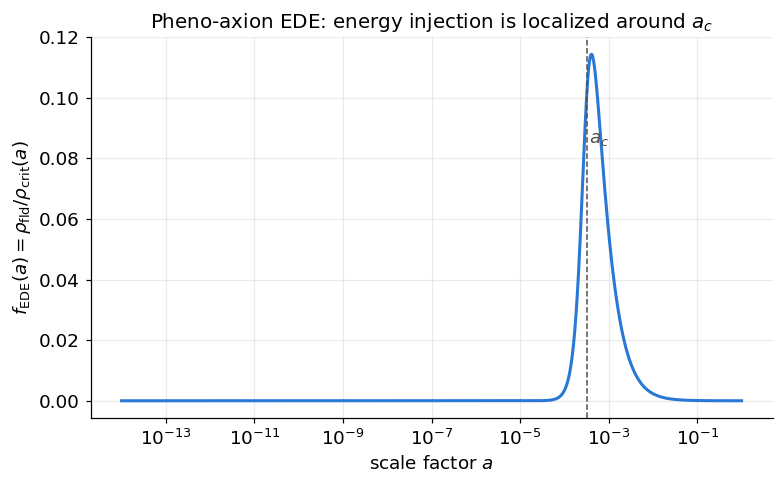

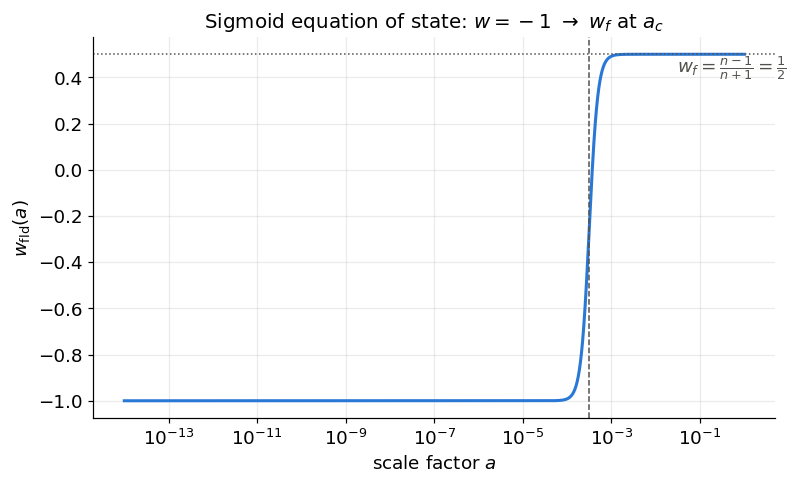

In [5]:
fig, ax = plt.subplots()
ax.semilogx(a_s, f_ede, color=C1)
ax.axvline(a_c, color=NEUTRAL, lw=1, ls="--")
ax.annotate(r"$a_c$", xy=(a_c * 1.15, 0.085), color=NEUTRAL)
ax.set(xlabel=r"scale factor $a$", ylabel=r"$f_{\rm EDE}(a)=\rho_{\rm fld}/\rho_{\rm crit}(a)$",
       title="Pheno-axion EDE: energy injection is localized around $a_c$")
plt.show()

fig, ax = plt.subplots()
ax.semilogx(a_s, w_fld, color=C1)
ax.axvline(a_c, color=NEUTRAL, lw=1, ls="--")
ax.axhline(0.5, color=NEUTRAL, lw=1, ls=":")
ax.annotate(r"$w_f=\frac{n-1}{n+1}=\frac{1}{2}$", xy=(3e-2, 0.42), color=NEUTRAL)
ax.set(xlabel=r"scale factor $a$", ylabel=r"$w_{\rm fld}(a)$",
       title=r"Sigmoid equation of state: $w=-1\ \to\ w_f$ at $a_c$")
plt.show()
ede_bg.struct_cleanup(); ede_bg.empty()

The background behavior matches theory to high precision (numbers from the PR's
validation suite, reproduced by the cell above): the plateau is flat to
$2\times10^{-7}$, the dilution tail scales as $a^{-4.500}$
($-3(1+w_f)=-4.5$ exactly), and $f_{\rm EDE}(a_c)$ reproduces the input fraction to
$4\times10^{-7}$ — the $\Omega_{\rm fld,0}\leftrightarrow f_{\rm EDE}(a_c)$ conversion
is exact for the fluid itself (closed-form integral), with only the neutrino-scaling
approximation of $\Omega_{\rm tot}(a_c)$ entering the fraction definition.

## 4. Impact on the CMB

The canonical EDE point shifts the acoustic peaks — the classic EDE signature
(extra energy density around matter–radiation equality shrinks the sound horizon;
with all other parameters held fixed the peaks move).

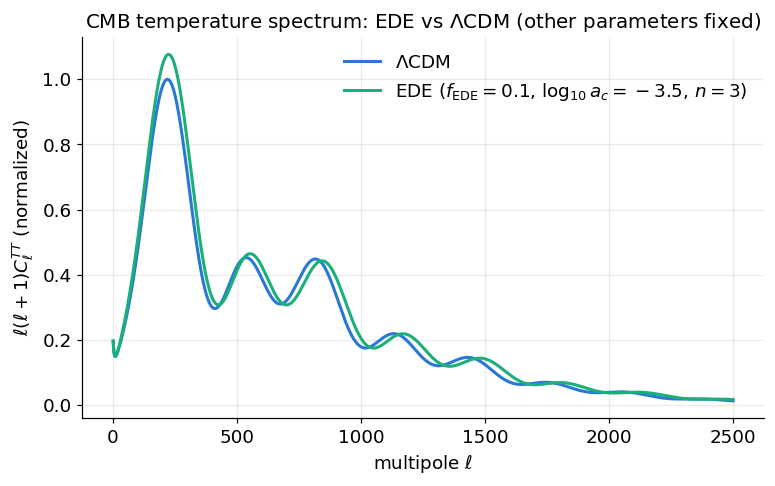

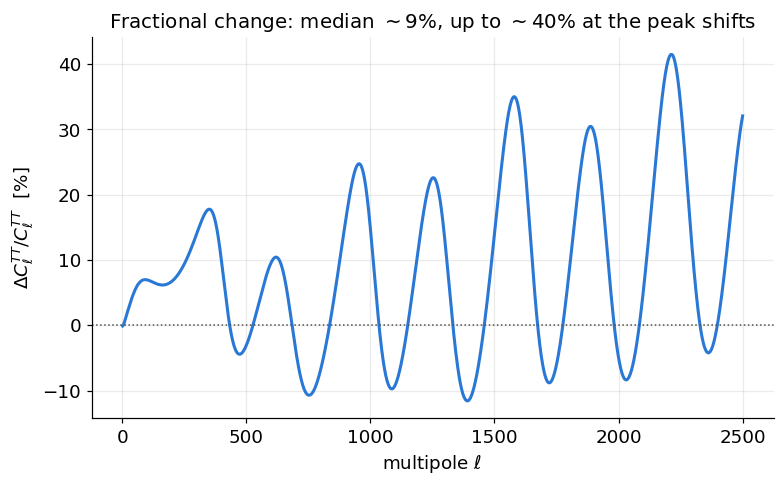

median |dCl/Cl| = 0.087,  max = 0.415 at l = 2213


In [6]:
lcdm = run({"output": "tCl"})
ede = run({**EDE, "output": "tCl"})

cl0 = lcdm.raw_cl(2500)
cl1 = ede.raw_cl(2500)
ell = cl0["ell"][2:]
dl0 = cl0["tt"][2:] * ell * (ell + 1)
dl1 = cl1["tt"][2:] * ell * (ell + 1)

fig, ax = plt.subplots()
ax.plot(ell, dl0 / dl0.max(), color=C1, label=r"$\Lambda$CDM")
ax.plot(ell, dl1 / dl0.max(), color=C2, label=r"EDE ($f_{\rm EDE}=0.1$, $\log_{10}a_c=-3.5$, $n=3$)")
ax.set(xlabel=r"multipole $\ell$", ylabel=r"$\ell(\ell+1)C_\ell^{TT}$ (normalized)",
       title="CMB temperature spectrum: EDE vs $\\Lambda$CDM (other parameters fixed)")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(ell, 100 * (dl1 / dl0 - 1), color=C1)
ax.axhline(0, color=NEUTRAL, lw=1, ls=":")
ax.set(xlabel=r"multipole $\ell$", ylabel=r"$\Delta C_\ell^{TT}/C_\ell^{TT}$  [%]",
       title="Fractional change: median $\\sim$9%, up to $\\sim$40% at the peak shifts")
plt.show()
med = np.median(np.abs(dl1 / dl0 - 1)); mx = np.max(np.abs(dl1 / dl0 - 1))
print(f"median |dCl/Cl| = {med:.3f},  max = {mx:.3f} at l = {ell[np.argmax(np.abs(dl1/dl0-1))]}")

## 5. Consistency checks

**Decoupling.** Sending the EDE fraction to $10^{-8}$ must reproduce $\Lambda$CDM.
The residual is at the $2\times10^{-5}$ level — numerical noise, far below cosmic
variance.

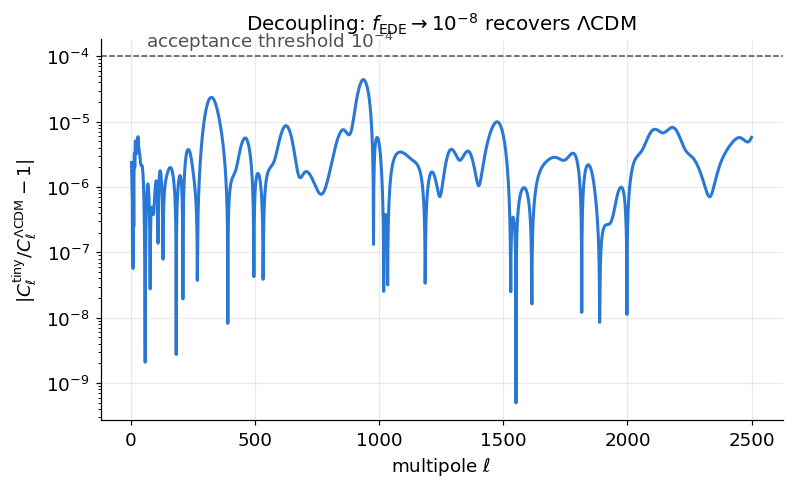

max residual = 4.41e-05


In [7]:
tiny = run({**EDE, "fraction_fld_ac": 1e-8, "output": "tCl"})
clt = tiny.raw_cl(2500)
ratio = np.abs(clt["tt"][2:] / cl0["tt"][2:] - 1)

fig, ax = plt.subplots()
ax.semilogy(ell, ratio, color=C1)
ax.axhline(1e-4, color=NEUTRAL, lw=1, ls="--")
ax.annotate("acceptance threshold $10^{-4}$", xy=(60, 1.4e-4), color=NEUTRAL)
ax.set(xlabel=r"multipole $\ell$", ylabel=r"$|C_\ell^{\rm tiny}/C_\ell^{\Lambda\rm CDM}-1|$",
       title=r"Decoupling: $f_{\rm EDE}\to10^{-8}$ recovers $\Lambda$CDM")
plt.show()
print(f"max residual = {ratio.max():.2e}")
for c in (lcdm, ede, tiny):
    c.struct_cleanup(); c.empty()

**Guard rails.** Integration testing surfaced two pre-existing module checks that were
incompatible with a fluid whose $w\to-1$ asymptotically; both are now species-owned
virtuals (see PR #370):

- `FluidSpecies::ReachesPhantomDivide()` — the historical `perturb_init` test fired on
  the *exact* $w(a{=}0)=-1$ asymptote; the sigmoid never reaches $-1$ at any $a>0$.
- `FluidSpecies::HyrecCplApproximation()` — HyRec reconstructs its internal
  dark-energy density from a single CPL $(w_0,w_a)$ pair (`hyrec/history.c`), which
  cannot represent $\Lambda$ + a frozen$\to$diluting sigmoid; pheno-axion runs
  therefore **require `recombination = RECFAST`** (the default, which reads the true
  background table). HyRec fails fast with an actionable message
  (proper fix — feeding HyRec the true $H(z)$ — is issue
  [#369](https://github.com/AarhusCosmology/CLASSpp/issues/369)):

In [8]:
from classy import CosmoComputationError
bad = Class()
bad.set({**BASE, **EDE, "output": "tCl", "recombination": "HyRec"})
try:
    bad.compute()
except CosmoComputationError as err:
    msg = str(err)
    print(msg[msg.find("condition"):][:400])
bad.struct_cleanup(); bad.empty()

condition (!fld.HyrecCplApproximation(&param.w0, &param.wa)) is true; this fluid's dark-energy density history cannot be represented by the CPL (w0, wa) pair that HyRec uses internally (hyrec/history.c) — HyRec would misreconstruct H(z) at recombination. Use 'recombination = RECFAST', which reads the true background table.


## 6. Validity, limitations and follow-ups

| regime | tool | status |
|---|---|---|
| frozen / slowly thawing field ($m \lesssim 10^2 H_0$) | component 1 (exact KG) | ✔ this PR |
| deep-oscillation EDE ($a_c \ll 1$, $10^{5+}$ cycles) | component 2 (effective fluid) | ✔ this PR |
| KG $\to$ fluid runtime switching (AxiCLASS `scf_evolve_as_fluid`) | — | issue [#365](https://github.com/AarhusCosmology/CLASSpp/issues/365) |
| axion inside the Type-3 momentum-transfer composite | — | issue [#366](https://github.com/AarhusCosmology/CLASSpp/issues/366) |
| $f_{\rm EDE}$-peak derived parameters via the wrapper | — | issue [#367](https://github.com/AarhusCosmology/CLASSpp/issues/367) |
| `phi_2n` / `axionquad` potentials | — | issue [#368](https://github.com/AarhusCosmology/CLASSpp/issues/368) |
| HyRec with the true $H(z)$ (also fixes silent scf-DE approximation) | — | issue [#369](https://github.com/AarhusCosmology/CLASSpp/issues/369) |

Two AxiCLASS bugs were deliberately **not** ported: the C comma-operator slip in the
analytic $\mathrm{d}w/\mathrm{d}a$ (rederived and verified against finite differences)
and the $n=1$-singular $V''$ (replaced by the regular form of §2). The unit tests
(`test-scf-potential`, `test-axion-scf-factory`, `test-axion-ede-fluid`) verify the
potential derivatives against finite differences, the closed-form density integral
against quadrature, the $c_s^2$ limits ($k\to0$: $w_f$; $k\to\infty$: 1), the
$\Omega$ round-trips, and every input-validation rejection branch.

In [9]:
import subprocess
from importlib.metadata import version
print("HEAD:", subprocess.run(["git", "log", "--oneline", "-1"], capture_output=True,
                              text=True, cwd="..").stdout.strip())
print("classy-community", version("classy-community"))

HEAD: 871373f5 Harden pheno_axion edges: unreachable base ComputeWFld case, positive-density check
classy-community 26.0.0
